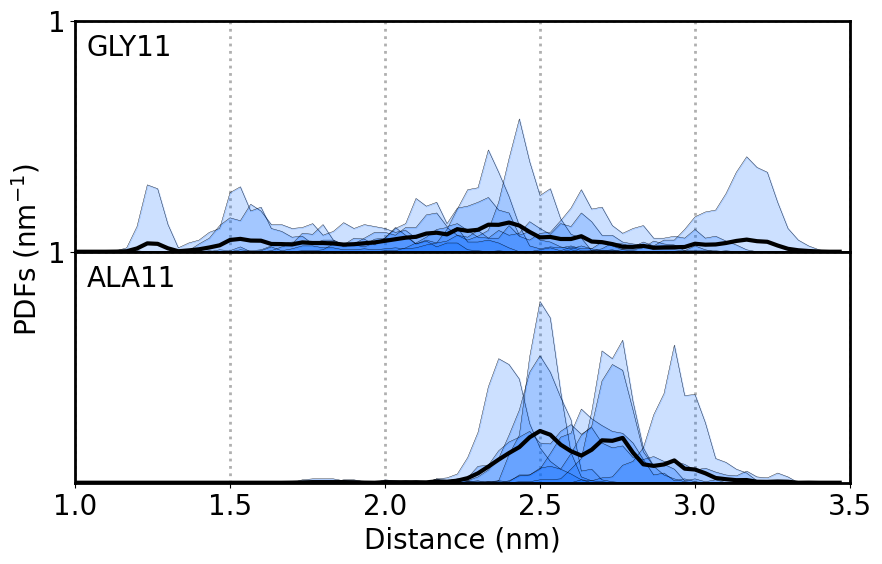

In [3]:
import numpy as np
from scipy.stats import sem
import matplotlib.pyplot as plt


plt.rc("axes", axisbelow=True)
plt.rcParams.update({"font.size": 20})

N_TRJ = 8
SYSTEMS = [
    "GLY11",
    "ALA11",
]
RESULTS = "../output_files"
SELECTION_NAME = "peptide_end_to_end"
N_BINS = 75
XLIM = (10, 35)
YLIM = (0, 1)

fig, axs = plt.subplots(len(SYSTEMS), 1, figsize=(10, 6), sharex=True, sharey=True)
fig.text(0.06, 0.5, r"PDFs ($\mathrm{nm}^{-1}$)", va="center", rotation="vertical")
axs = axs.flatten()
for i, system in enumerate(SYSTEMS):
    hist_array = np.zeros((N_TRJ, N_BINS))
    for j in range(N_TRJ):
        data = np.loadtxt(f"{RESULTS}/{system}_T{j}_distance_{SELECTION_NAME}.dat")
        hist, bin_edges = np.histogram(data, bins=N_BINS, range=XLIM, density=True)
        axs[i].plot(bin_edges[:-1], hist, color="black", linewidth=0.25)
        axs[i].fill_between(bin_edges[:-1], hist, color="#0066ff", alpha=0.2)
        hist_array[j] = hist
    hist_mean = np.mean(hist_array, axis=0)
    axs[i].plot(bin_edges[:-1], hist_mean, color="black", linewidth=3)
    axs[i].set_xlim(XLIM)
    axs[i].set_ylim(YLIM)
    axs[i].set_yticks((1,))
    axs[i].grid(linewidth=2, linestyle=":")
    axs[i].spines[:].set_linewidth(2)
    axs[i].text(
        XLIM[0]+0.015*(XLIM[1]-XLIM[0]),
        YLIM[0]+0.85*(YLIM[1]-YLIM[0]),
        system
    )
if CALCULATE_MEAN:
    axs[0].legend(fontsize=14, loc="upper right")
axs[1].set_xlabel("E2E (nm)")
axs[1].set_xticks([10, 15, 20, 25, 30, 35], labels=[1.0, 1.5, 2.0, 2.5, 3.0, 3.5])
plt.subplots_adjust(wspace=0.1, hspace=0)